# DSW timing

In [1]:
import xarray as xr
import numpy as np
import cosima_cookbook as cc
from dask.distributed import Client
import cftime
from datetime import timedelta
from gsw import alpha, SA_from_SP, p_from_z, CT_from_pt, beta, sigma1, sigma2
import matplotlib.path as mpath

import matplotlib.pyplot as plt
import cmocean.cm as cmo
import glob

We need to figure out whether stronger DSW outflow is driving resolution changes, stronger SWMT is driving resolution changes or stronger HT is driving resolution changes. To figure that out we can use the firat year of each simulation and calculate....

[a] Monthly/Daily timeseries of DSW export in each resolution

[b] Monthly/Daily timeseries of SWMT in each resolution

Which one has the first increase with resolution? Do we see a increase in DSW export with resolution right away? Or do we see an increase in SWMT in winter, after a first period with similar DSW export? 



In [2]:
#importing SWMT data
SWMT_01=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/\
SWMT_sigma2_panan_01deg_jra55_ryf_1m_199*.nc').isel(time=slice(0,24))

SWMT_005=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/\
SWMT_sigma2_panan_005deg_jra55_ryf_1m_199*.nc').isel(time=slice(0,24))

SWMT_0025=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/\
SWMT_sigma2_panan_0025deg_jra55_ryf_1m_199*.nc').isel(time=slice(0,24))


#importing DSW outflow data
DSW_01=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/\
vol_transp_across_1000m_isobath_panan_01deg_jra55_ryf_1m_199*.nc')

DSW_005=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/\
vol_transp_across_1000m_isobath_panan_005deg_jra55_ryf_1m_199*.nc')

DSW_0025=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/\
vol_transp_across_1000m_isobath_panan_0025deg_jra55_ryf_1m_199*.nc')

Calculating the monthly mean DSW export in the first year

In [9]:
#DSW outflow timeseries

DSW_01_tseries = DSW_01.sum('contour_index').where(DSW_01.rho2_l>=1037.2).sum('rho2_l')

DSW_005_tseries = DSW_005.sum('contour_index').where(DSW_005.rho2_l>=1037.2).sum('rho2_l')

DSW_0025_tseries = DSW_0025.sum('contour_index').where(DSW_0025.rho2_l>=1037.2).sum('rho2_l')

Text(0.5, 1.0, 'Monthly DSW export $\\sigma_2>1037.18\\ kg\\ m^{-3}$')

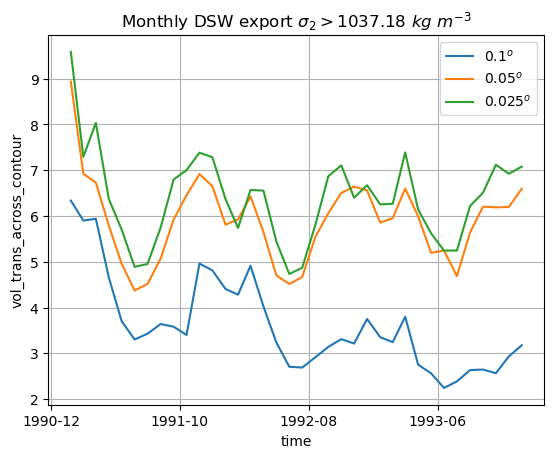

In [10]:
#Timeseries
DSW_01_tseries.vol_trans_across_contour[:36].plot(label=r"$0.1^o$")
DSW_005_tseries.vol_trans_across_contour[:36].plot(label=r"$0.05^o$")
DSW_0025_tseries.vol_trans_across_contour[:36].plot(label=r"$0.025^o$")
plt.grid(); plt.legend()
plt.title(r"Monthly DSW export $\sigma_2>1037.18\ kg\ m^{-3}$")

What about th SWMT, does that happen only after DSW export?

In [5]:
##Lets use the 1000m isobaths to mask regions outside the shelf

#importing isobaths
Iso01=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/Antarctic_slope_contours/\
Antarctic_slope_contour_1000m_MOM6_01deg.nc').isel(yh=slice(0,460))
Iso01=Iso01.where(Iso01.contour_masked_above>-1000)*0

# Iso005=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/Antarctic_slope_contours/\
# Antarctic_slope_contour_1000m_MOM6_005deg.nc').isel(yh=slice(0,919))
# Iso005=Iso005.where(Iso005.contour_masked_above>-1000)*0

# Iso0025=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/Antarctic_slope_contours/\
# Antarctic_slope_contour_1000m_MOM6_0025deg.nc').isel(yh=slice(0,1839))
#Iso0025=Iso0025.where(Iso0025.contour_masked_above>-1000)*0

In [6]:
#importing Tarea
session = cc.database.create_session()
Tarea01 = cc.querying.getvar('panant-01-zstar-ACCESSyr2','areacello',session,n=1).isel(yh=slice(0,460))
Tarea005 = cc.querying.getvar('panant-005-zstar-ACCESSyr2','areacello',session,n=1).isel(yh=slice(0,919))
Tarea0025 = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','areacello',session,n=1).isel(yh=slice(0,1839))

In [7]:
def shelf_mask_isobath(var, contour_depth, resolution, output_mask=False):
    '''
    Masks variales by the region polewards of a given isobath
    '''
    
    ds_contour = xr.open_dataset(
        '/home/142/cs6673/work/mom6_comparison/Antarctic_slope_contours/' +
        'Antarctic_slope_contour_' + str(contour_depth) + 'm_MOM6_' +
        resolution + 'deg.nc')
    
    shelf_mask = ds_contour.contour_masked_above.sel(yh=slice(var.yh[0], var.yh[-1]))
    yh = ds_contour.yh.sel(yh=slice(var.yh[0], var.yh[-1]))
    xh = ds_contour.xh
    
    # in this file the points along the isobath are given a positive value, the points outside (northwards) 
    # of the isobath are given a value of -100 and all the points on the continental shelf have a value of 0 
    # so we mask for the 0 values 
    shelf_mask = shelf_mask.where(shelf_mask == 0)+1
    shelf_mask = shelf_mask.where(shelf_mask == 1, 0)
    
    # multiply the variable with the mask
    masked_var = var * shelf_mask
    
    if output_mask == True:
        return masked_var, shelf_mask
    else:
        return masked_var

In [8]:
#masking shelf
######### Notice that when masking the shelf we get the isopycnal bin closest to the 37.2, 
######## not all the ones bigger to it. That is because christina saved the bins as already 
######## cumsummed from the highest density bin

#Panan01
SHeat_1dz_shelf = shelf_mask_isobath(SWMT_01.binned_heat_transformation, 1000, '01')
Ssalt_1dz_shelf = shelf_mask_isobath(SWMT_01.binned_salt_transformation, 1000, '01')
SWMT_01_t=((SHeat_1dz_shelf+Ssalt_1dz_shelf)*Tarea01).isel(isopycnal_bins=80)
SWMT_01_t=SWMT_01_t.sum('xh').sum('yh')
del SHeat_1dz_shelf,Ssalt_1dz_shelf

#Panan005
SHeat_1dz_shelf = shelf_mask_isobath(SWMT_005.binned_heat_transformation, 1000, '005')
Ssalt_1dz_shelf = shelf_mask_isobath(SWMT_005.binned_salt_transformation, 1000, '005')
SWMT_005_t=((SHeat_1dz_shelf+Ssalt_1dz_shelf)*Tarea005).isel(isopycnal_bins=80)
SWMT_005_t=SWMT_005_t.sum('xh').sum('yh')
del SHeat_1dz_shelf,Ssalt_1dz_shelf


#Panan0025
SHeat_1dz_shelf = shelf_mask_isobath(SWMT_0025.binned_heat_transformation, 1000, '0025')
Ssalt_1dz_shelf = shelf_mask_isobath(SWMT_0025.binned_salt_transformation, 1000, '0025')
SWMT_0025_t=((SHeat_1dz_shelf+Ssalt_1dz_shelf)*Tarea0025).isel(isopycnal_bins=80)
SWMT_0025_t=SWMT_0025_t.sum('xh').sum('yh')
del SHeat_1dz_shelf,Ssalt_1dz_shelf


In [9]:
SWMT_01_t.load()
SWMT_005_t.load()
SWMT_0025_t.load()

<xarray.DataArray (time: 24)>
array([       0.        ,        0.        ,  1904057.17511595,
        6649270.41592495, 14945171.83378818,  8992504.83154576,
       13951178.61139642, 15736564.04004693, 15424678.40816339,
        6297391.55516992, -1640385.52275532,  -145745.42612618,
              0.        ,        0.        ,  2281369.16716632,
        8354927.34321814, 11494774.09331258,  9209016.12076531,
       11701034.00781897, 10748919.54297249, 12140042.79337697,
        3874258.83872332, -1316576.19788076,  -115366.10913532])
Coordinates:
  * time            (time) object 1991-01-16 12:00:00 ... 1992-12-16 12:00:00
    isopycnal_bins  float64 37.2
    z_l             float64 0.5413

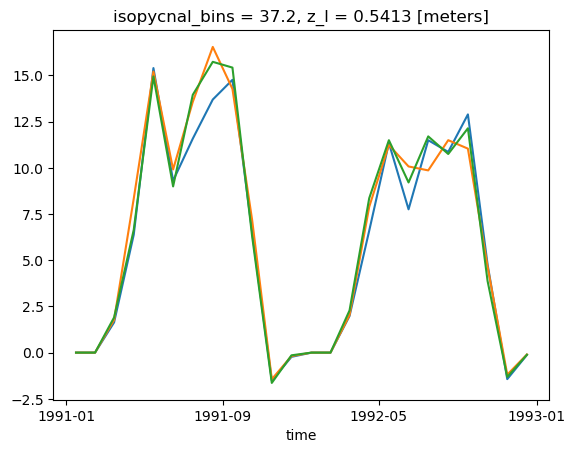

In [10]:
(SWMT_01_t/1e6).plot()
(SWMT_005_t/1e6).plot()
(SWMT_0025_t/1e6).plot()

Although we dont have the final figure already, from previous plots we can see that the DSW outflow is already bigger from the first month, while SWMT on the shelf only happens after a few months. So likely a better resolved outflow speed up the whole process.


But, why is the outflow better represented? we will have to look into the Dynamics of it

Lets do a combined figure


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Shelf WMT [SV]')

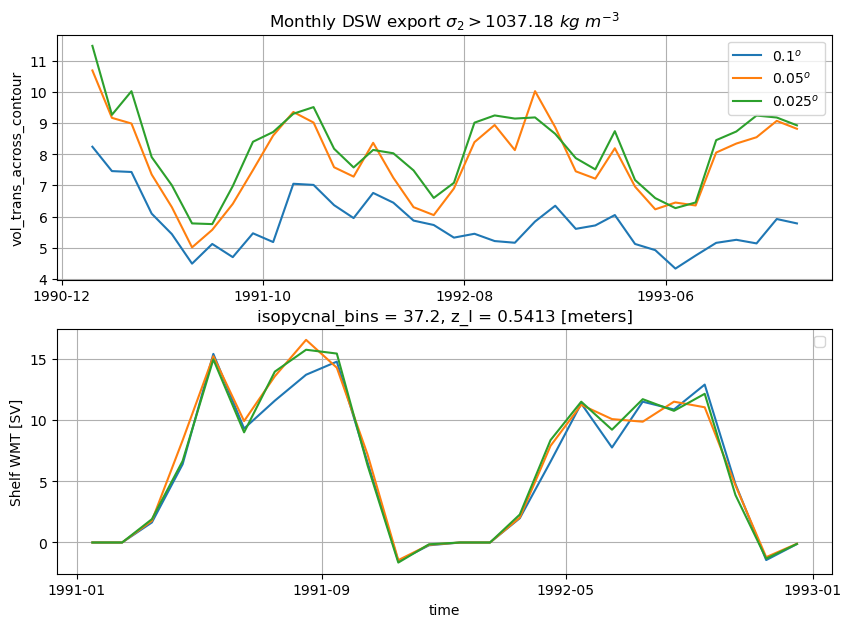

In [11]:
#Timeseries
plt.figure(figsize=(10,7))
plt.subplot(2,1,1)
DSW_01_tseries.vol_trans_across_contour[:36].plot(label=r"$0.1^o$")
DSW_005_tseries.vol_trans_across_contour[:36].plot(label=r"$0.05^o$")
DSW_0025_tseries.vol_trans_across_contour[:36].plot(label=r"$0.025^o$")
plt.grid(); plt.legend();plt.xlabel('')
plt.title(r"Monthly DSW export $\sigma_2>1037.18\ kg\ m^{-3}$")

plt.subplot(2,1,2)
(SWMT_01_t/1e6).plot()
(SWMT_005_t/1e6).plot()
(SWMT_0025_t/1e6).plot()
plt.grid(); plt.legend()
plt.ylabel(r"Shelf WMT [SV]")

It seems like we have stronger overflow across the 1000m isobath from the beggining already, with substatially weaker overflow in $0.1^o$ than in $0.05^o$. The a small increase from $0.05^o$ to $0.025^o$. SWMT happens only a little after, and doenst show much signal (probably because Im using the same density level). [According to Winton 1998](https://journals.ametsoc.org/view/journals/phoc/28/11/1520-0485_1998_028_2163_soddfd_2.0.co_2.xml) a optimal horizonal resolution of $\Delta x = \Delta Z/slope$ it is required to fully solve the downslope plume. That is because a horizonal resolution that is too coasrse, can misrepresent the slope and cause too much mixing along the slope ( make the downslope plume too light). Using a typical slope of 0.01, and a typical 

In [11]:
session = cc.database.create_session()
exp = 'panant-01-zstar-ACCESSyr2'
rho_0 = 1035.0
# specific heat capacity of sea water:
cp = 3992.1
lat_range = slice(-90,-59)

In [35]:
z_l= cc.querying.getvar(exp,'z_l',session,n=1)
z_i= cc.querying.getvar(exp,'z_i',session,n=1)
dzt=np.diff(z_i)
dzt=xr.DataArray(dzt,dims=["z_l"],name='dzt')
dzt['z_l']=np.array(z_l)

In [65]:
dxt01masked = dxt01.where(ht01<1300).sel(yh=lat_range)
dxt005masked = dxt005.where(ht005<1300).sel(yh=lat_range)
dxt0025masked = dxt0025.where(ht0025<1300).sel(yh=lat_range)

In [140]:
dxt01= cc.querying.getvar(exp,'dxt',session,n=1)/1000
dxt005= cc.querying.getvar('panant-005-zstar-ACCESSyr2','dxt',session,n=1)/1000
dxt0025= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','dxt',session,n=1)/1000

#getting the dz at the bottom of each grid cell 

#panan01
ht01= cc.querying.getvar(exp,'thetao',session,n=1).isel(time=0)
ht01b=ht01.copy(); ht01b['z_l']=np.append(0,np.array(z_l[:-1]))
ht01a =ht01*0 + ht01.z_l; ht01b =ht01b*0 + ht01b.z_l; 
ht01a=ht01a.sel(yh=lat_range); ht01b=ht01b.sel(yh=lat_range);
delta_Z01bath=ht01a.max('z_l')-ht01b.max('z_l')
delta_Z01bath.load()


#panan005
ht005= cc.querying.getvar('panant-005-zstar-ACCESSyr2','thetao',session,n=1).isel(time=0)
ht005b=ht005.copy(); ht005b['z_l']=np.append(0,np.array(z_l[:-1]))
ht005a =ht005*0 + ht005.z_l; ht005b =ht005b*0 + ht005b.z_l; 
ht005a=ht005a.sel(yh=lat_range); ht005b=ht005b.sel(yh=lat_range);
delta_Z005bath=ht005a.max('z_l')-ht005b.max('z_l')
delta_Z005bath.load()


#panan0025
ht0025= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','thetao',session,n=1).isel(time=0)
ht0025b=ht0025.copy(); ht0025b['z_l']=np.append(0,np.array(z_l[:-1]))
ht0025a =ht0025*0 + ht0025.z_l; ht0025b =ht0025b*0 + ht0025b.z_l; 
ht0025a=ht0025a.sel(yh=lat_range); ht0025b=ht0025b.sel(yh=lat_range);
delta_Z0025bath=ht0025a.max('z_l')-ht0025b.max('z_l')
delta_Z0025bath.load()



<xarray.DataArray (yh: 2038, xh: 14400)>
array([[         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       ...,
       [127.76929761, 127.76929761, 127.76929761, ..., 127.76929761,
        127.76929761, 127.76929761],
       [120.30834724, 127.76929761, 127.76929761, ..., 120.30834724,
        120.30834724, 120.30834724],
       [120.30834724, 120.30834724, 127.76929761, ..., 120.30834724,
        120.30834724, 120.30834724]])
Coordinates:
  * xh       (xh) float64 -280.0 -280.0 -279.9 -279.9 ... 79.94 79.96 79.99
  * yh       (yh) float64 -81.09 -81.08 -81.07 -81.06 ... -59.03 -59.01 -59.0
    time     object 1991-01-16 12:00:00

In [142]:
#importing the slopes
slope01=xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/slope_transpose_panan01.nc')
slope005=xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/slope_transpose_panan005.nc')

In [143]:
#the slope will be
slope01_t=slope01.slope_u.interp(xq=dxt01.xh)
slope005_t=slope005.slope_u.interp(xq=dxt005.xh)



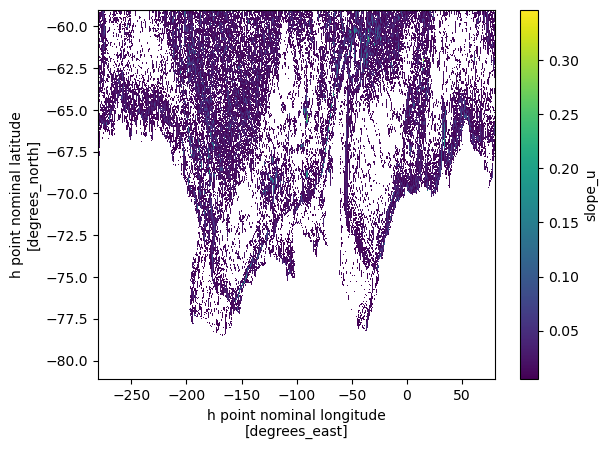

In [159]:
slope01_t.where(slope01_t>0.005).plot()

In [170]:
ht01a

<xarray.DataArray (z_l: 75, yh: 510, xh: 3600)>
dask.array<getitem, shape=(75, 510, 3600), dtype=float64, chunksize=(11, 121, 515), chunktype=numpy.ndarray>
Coordinates:
  * xh       (xh) float64 -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
  * yh       (yh) float64 -81.11 -81.07 -81.02 -80.98 ... -59.14 -59.08 -59.03
  * z_l      (z_l) float64 0.5413 1.681 2.94 ... 5.313e+03 5.511e+03 5.709e+03
    time     object 1991-01-16 12:00:00

In [185]:
# the required dxt will be
ht01amax=ht01a.max('z_l')
req_dx01=(delta_Z01bath/slope01_t.where(slope01_t>0.005))/1000; 
req_dx01=req_dx01.where((ht01amax<=2500) & (ht01amax>=500))

ht005amax=ht005a.max('z_l')
req_dx005=(delta_Z005bath/slope005_t.where(slope005_t>0.005))/1000
req_dx005=req_dx005.where((ht005amax<=2500) & (ht005amax>=500))



Text(0.5, 1.0, 'Resoltion required to solve the slope [km]')

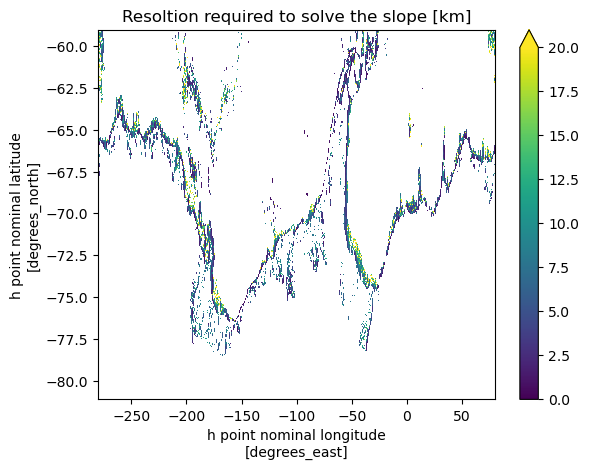

In [191]:
req_dx01.plot(vmin=0,vmax=20)
plt.title('Resoltion required to solve the slope [km]')

Lets now divide the dxt by the required resolution. That means that when the ratio is <1, the slope is well resolved, when is >1 it is not


In [215]:
#This slope slotion is a binaty matrix where 1 means slope is not resolved and 0 means slope is resolved
Slope_solving01 = dxt01masked/req_dx01; Slope_solving01=Slope_solving01.where((Slope_solving01>=1) & (Slope_solving01!=np.nan),0)
Slope_solving005 = dxt005masked/req_dx005 ; Slope_solving005=Slope_solving005.where((Slope_solving005>=1) ,0)

(-60.0, -40.0)

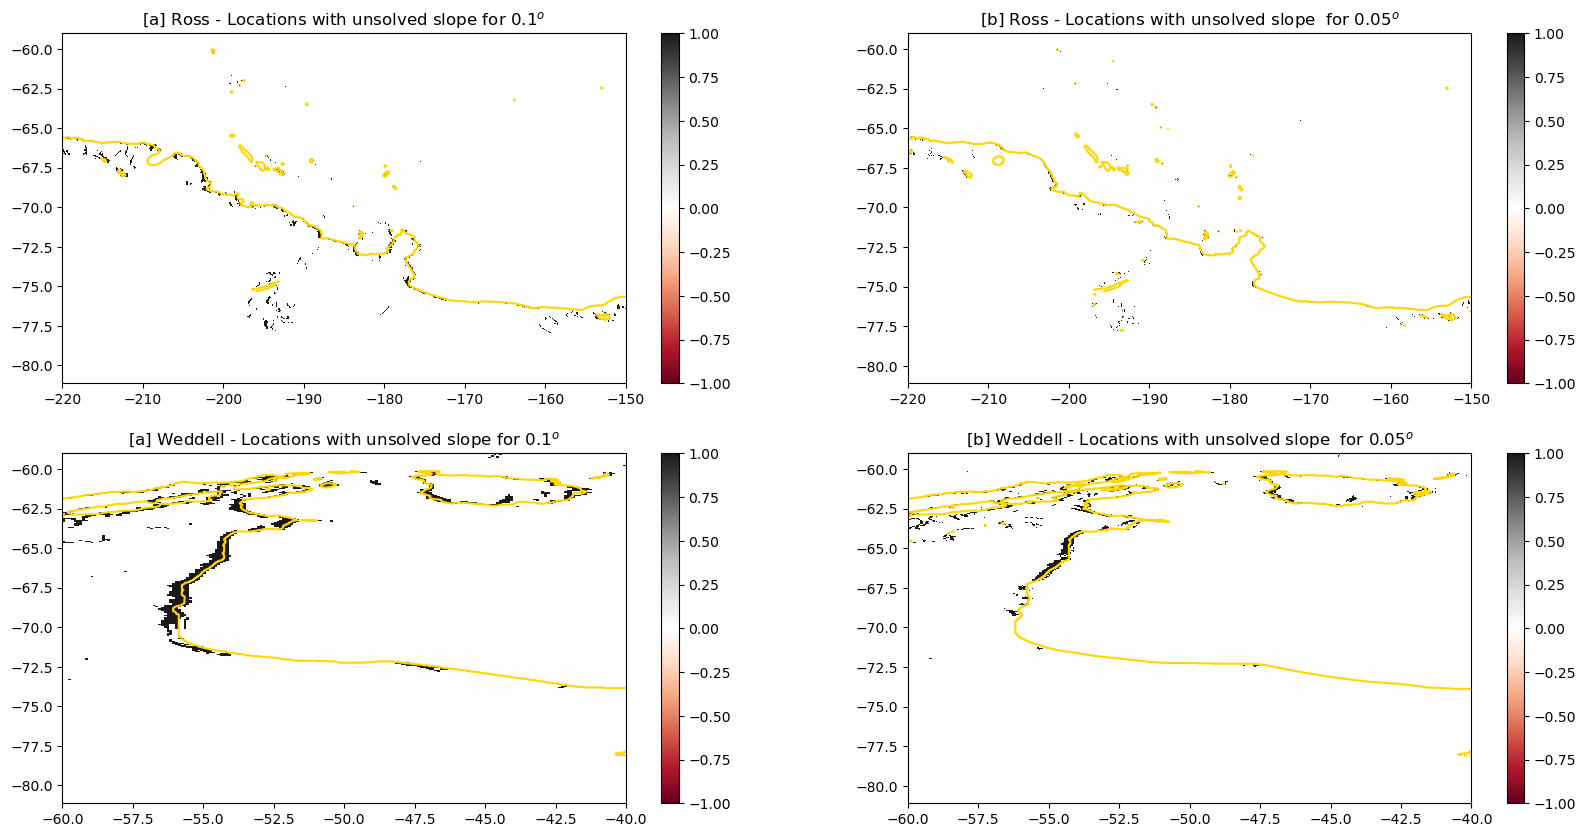

In [229]:
plt.figure(figsize=(20,10))


# Ross Sea
plt.subplot(2,2,1)
plt.contour(ht01amax.xh,ht01amax.yh,ht01amax,[1000],colors='gold',lw=0.1)
plt.pcolormesh(Slope_solving01.xh,Slope_solving01.yh,Slope_solving01,vmin=-1,vmax=1,cmap='RdGy')
plt.colorbar();plt.title(r"[a] Ross - Locations with unsolved slope for $0.1^o$")

plt.xlim(-220,-150)

plt.subplot(2,2,2)
plt.contour(ht005amax.xh,ht005amax.yh,ht005amax,[1000],colors='gold',lw=0.1)
plt.pcolormesh(Slope_solving005.xh,Slope_solving005.yh,Slope_solving005,vmin=-1,vmax=1,cmap='RdGy')
plt.colorbar();plt.title(r"[b] Ross - Locations with unsolved slope  for $0.05^o$")
plt.xlim(-220,-150)



# Weddell
plt.subplot(2,2,3)
plt.contour(ht01amax.xh,ht01amax.yh,ht01amax,[1000],colors='gold',lw=0.1)
plt.pcolormesh(Slope_solving01.xh,Slope_solving01.yh,Slope_solving01,vmin=-1,vmax=1,cmap='RdGy')
plt.colorbar();plt.title(r"[a] Weddell - Locations with unsolved slope for $0.1^o$")

plt.xlim(-60,-40)

plt.subplot(2,2,4)
plt.contour(ht005amax.xh,ht005amax.yh,ht005amax,[1000],colors='gold',lw=0.1)
plt.pcolormesh(Slope_solving005.xh,Slope_solving005.yh,Slope_solving005,vmin=-1,vmax=1,cmap='RdGy')
plt.colorbar();plt.title(r"[b] Weddell - Locations with unsolved slope  for $0.05^o$")
plt.xlim(-60,-40)

Text(0, 0.5, '[d] Resolution required to solve the slope of 0.01 [km]')

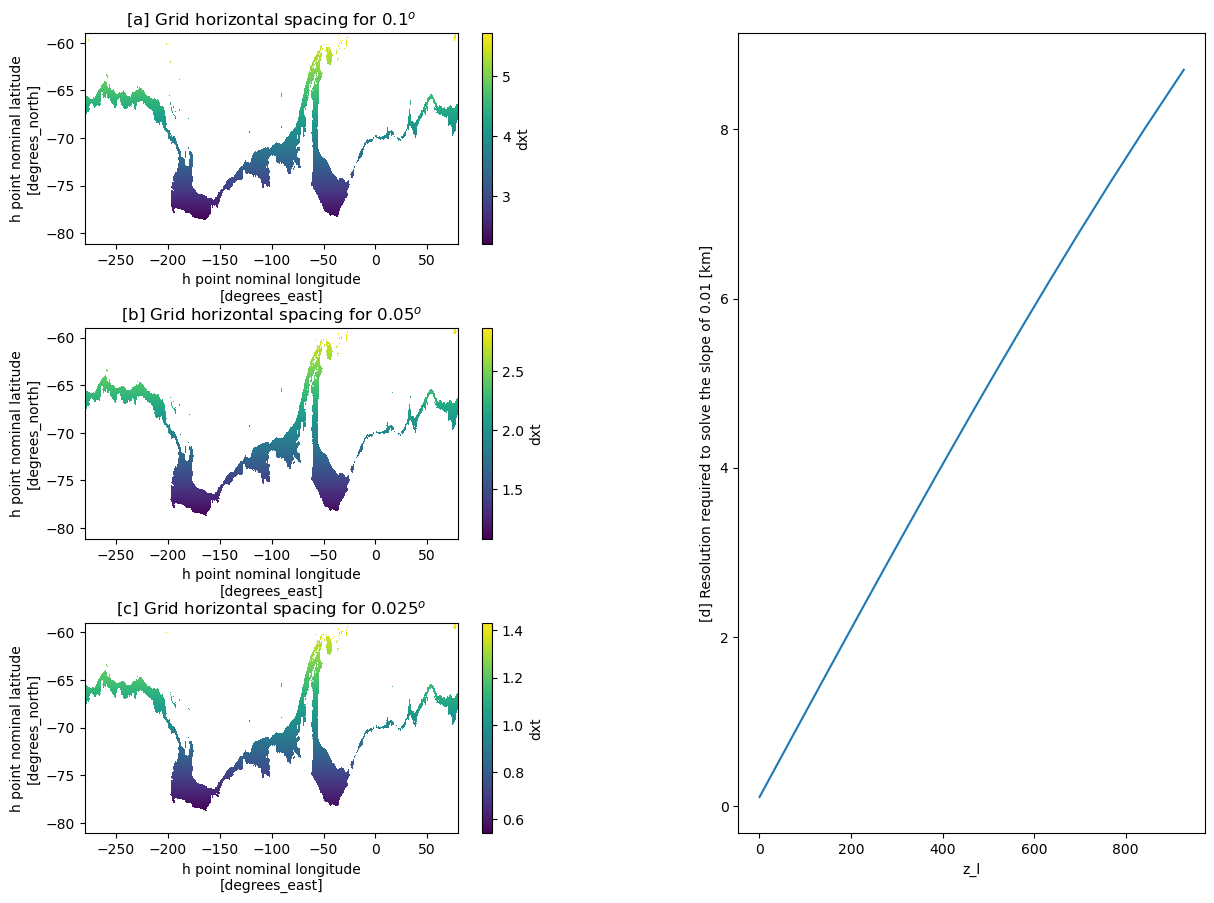

In [72]:
plt.figure(figsize=(14,10))


# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(3,2,1)
dxt01masked.plot(); plt.title(r"[a] Grid horizontal spacing for $0.1^o$")
plt.subplot(3,2,3)
dxt005masked.plot(); plt.title(r"[b] Grid horizontal spacing for $0.05^o$")
plt.subplot(3,2,5)
dxt0025masked.plot(); plt.title(r"[c] Grid horizontal spacing for $0.025^o$")
plt.subplot(1,2,2)
((dzt.where(z_l<1000)/0.01)/1000).plot()
plt.ylabel('[d] Resolution required to solve the slope of 0.01 [km]')

Now the curve above is linear, because we are using a singl slope value. lets get the actuall slope values
